# Análisis exploratorio de datos sobre ataques de tiburón

El dataset utilizado contiene registros históricos de ataques de tiburón. Cada registro incluye información relacionada con el caso, como el año, país, tipo de ataque, actividad que realizaba la persona, edad, lesión registrada y si el ataque fue fatal o no.

Dataset: https://www.kaggle.com/datasets/teajay/global-shark-attacks/data

## Preguntas guía

### Pregunta principal 1
**¿Qué actividades concentran la mayor cantidad de ataques registrados?**

A partir de esta pregunta se analizó la columna Activity, agrupando las actividades en categorías generales para poder compararlas mejor.

#### Análisis complementario
**¿Las actividades más frecuentes se mantienen al separarlas por rangos etarios?**

Este análisis se agregó para observar si las actividades con mayor presencia en el total general también aparecían como importantes en distintos grupos de edad.

---

### Pregunta principal 2
**¿Qué porcentaje de los ataques registrados fueron fatales?**

A partir de esta pregunta se limpió y analizó la columna Fatal (Y/N) para comparar los casos fatales y no fatales.

#### Análisis complementario
**¿Cómo varía la fatalidad según la actividad realizada?**

Este análisis se agregó para observar si las actividades con más ataques registrados también eran las que tenían mayor porcentaje de fatalidad.

#### Análisis complementario final
**¿Qué actividades presentan mayor peligrosidad relativa dentro del dataset?**

Para responder esto se construyó un índice de peligrosidad relativa, combinando el porcentaje de casos de cada actividad con su porcentaje de fatalidad.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

##Carga del dataset

In [72]:
df = pd.read_csv("attacks.csv", encoding="latin1", on_bad_lines="skip")
df.columns = df.columns.str.strip()

##Exploracion inicial del dataset

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25723 entries, 0 to 25722
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case Number             8702 non-null   str    
 1   Date                    6302 non-null   str    
 2   Year                    6300 non-null   float64
 3   Type                    6298 non-null   str    
 4   Country                 6252 non-null   str    
 5   Area                    5847 non-null   str    
 6   Location                5762 non-null   str    
 7   Activity                5758 non-null   str    
 8   Name                    6092 non-null   str    
 9   Sex                     5737 non-null   str    
 10  Age                     3471 non-null   str    
 11  Injury                  6274 non-null   str    
 12  Fatal (Y/N)             5763 non-null   str    
 13  Time                    2948 non-null   str    
 14  Species                 3464 non-null   str    
 

In [74]:
print(df.shape)

df.head()

(25723, 24)


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,...,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.09,2018.06.09,6301.0,NaN,NaN
3,2018.06.08,08-Jun-2018,2018.0,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,Surfing,male,M,...,2 m shark,"B. Myatt, GSAF",2018.06.08-Arrawarra.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.08,2018.06.08,6300.0,NaN,NaN
4,2018.06.04,04-Jun-2018,2018.0,Provoked,MEXICO,Colima,La Ticla,Free diving,Gustavo Ramos,M,...,"Tiger shark, 3m",A .Kipper,2018.06.04-Ramos.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.04,2018.06.04,6299.0,NaN,NaN


In [75]:
nulos = pd.DataFrame({
    "Cantidad_nulos": df.isnull().sum(),
    "Porcentaje_nulos": (df.isnull().sum() / len(df) * 100).round(2)})

nulos.sort_values("Porcentaje_nulos", ascending=False)

,Cantidad_nulos,Porcentaje_nulos
Unnamed: 22,25722,100.00
Unnamed: 23,25721,99.99
Time,22775,88.54
Species,22259,86.53
Age,22252,86.51
Sex,19986,77.70
Activity,19965,77.62
Location,19961,77.60
Fatal (Y/N),19960,77.60
Area,19876,77.27


In [76]:
print("Cantidad de filas duplicadas:")
print(df.duplicated().sum())

Cantidad de filas duplicadas:
19411


In [77]:
print("Filas totales originales:")
print(df.shape)

print("\nFilas completamente vacías:")
print(df.isnull().all(axis=1).sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

Filas totales originales:
(25723, 24)

Filas completamente vacías:
17020

Filas duplicadas:
19411


##Limpieza

###Creamos una copia y en ella eliminamos todas las filas completamente nulas y repetidas

In [78]:
df_copia = df.copy()

df_copia = df_copia.dropna(how="all").copy()
df_copia = df_copia.drop_duplicates().copy()

In [79]:
print(df_copia.shape)

(6311, 24)


In [80]:
nulos_copia = pd.DataFrame({
    "Cantidad_nulos": df_copia.isnull().sum(),
    "Porcentaje_nulos": (df_copia.isnull().sum() / len(df_copia) * 100).round(2)})

nulos_copia.sort_values("Porcentaje_nulos", ascending=False)

,Cantidad_nulos,Porcentaje_nulos
Unnamed: 22,6310,99.98
Unnamed: 23,6309,99.97
Time,3363,53.29
Species,2847,45.11
Age,2840,45.00
Sex,574,9.10
Activity,553,8.76
Location,549,8.70
Fatal (Y/N),548,8.68
Area,464,7.35


##Selecionamos columnas utiles

In [81]:
columnas_analisis = [
    "Year",
    "Type",
    "Country",
    "Activity",
    "Age",
    "Fatal (Y/N)"
]

df_limpio = df_copia[columnas_analisis].copy()

print(df_limpio.shape)

df_limpio.sample(10)

(6311, 6)


,Year,Type,Country,Activity,Age,Fatal (Y/N)
5263,1919.0,Unprovoked,AUSTRALIA,Swimming,29,N
1100,2009.0,Unprovoked,USA,Surfing,NaN,N
3660,1964.0,Unprovoked,AUSTRALIA,"Surfing, but swimming to his board",19,N
3296,1973.0,Unprovoked,MEXICO,"Free diving, Spearfishing",37,Y
3581,1966.0,Sea Disaster,PHILIPPINES,The passenger ship Pioneer Cebu capsized & sa...,NaN,Y
2705,1988.0,Sea Disaster,AUSTRALIA,"The Christie V sank on 11/6/1988, survivors we...",62,Y
1765,2003.0,Unprovoked,BRAZIL,NaN,NaN,Y
777,2012.0,Unprovoked,AUSTRALIA,Surf skiing,62,N
4681,1943.0,Sea Disaster,BRAZIL,The 3540-ton Alfonso Penna was torpedoed & sun...,NaN,Y
3143,1977.0,Invalid,USA,Wading,17,NaN


In [82]:
df_limpio["Type"].value_counts(dropna=False)

Type
Unprovoked      4595
Provoked         574
Invalid          547
Sea Disaster     239
Boating          203
Boat             137
NaN               13
Questionable       2
Boatomg            1
Name: count, dtype: int64

In [83]:
df_limpio["Activity"].value_counts(dropna=False).head(60)

Activity
Surfing                           971
Swimming                          869
NaN                               553
Fishing                           431
Spearfishing                      333
Bathing                           162
Wading                            149
Diving                            127
Standing                           99
Snorkeling                         89
Scuba diving                       76
Body boarding                      61
Body surfing                       49
Swimming                           47
Kayaking                           33
Treading water                     32
Fell overboard                     32
Pearl diving                       32
Free diving                        29
Boogie boarding                    29
Windsurfing                        19
Walking                            17
Boogie Boarding                    16
Shark fishing                      15
Floating                           14
Canoeing                           13
Fis

In [84]:
df_limpio["Age"].value_counts(dropna=False).head(30)

Age
NaN    2840
17      154
18      150
19      142
20      141
15      139
16      138
21      119
22      117
25      108
24      106
14      101
13       94
26       83
28       80
23       80
29       78
27       78
30       76
12       73
32       69
35       69
10       56
40       56
31       52
34       50
38       48
33       44
36       43
43       43
Name: count, dtype: int64

In [85]:
df_limpio["Fatal (Y/N)"].value_counts(dropna=False)

Fatal (Y/N)
N          4293
Y          1388
NaN         548
UNKNOWN      71
 N            7
M             1
2017          1
N             1
y             1
Name: count, dtype: int64

##Pregunta 1 ¿Qué actividades concentran la mayor cantidad de ataques registrados?

##Preparar datos para el analisis

La columna Activity, tiene datos muy variados que pueden apuntar a lo mismo o mismo tipo de actividad, por lo tanto se decide crear categorias para facilitar la comparacion

In [86]:
def categorizar_actividad(actividad):
    if pd.isna(actividad):
        return "Sin dato"

    actividad = str(actividad).lower().strip()

    if "surf" in actividad or "board" in actividad or "paddl" in actividad:
        return "Surf / board"
    elif "swim" in actividad or "bathing" in actividad:
        return "Natación / baño"
    elif "fish" in actividad:
        return "Pesca"
    elif "div" in actividad or "snorkel" in actividad:
        return "Buceo / snorkel"
    elif "wading" in actividad or "standing" in actividad or "walking" in actividad:
        return "Orilla / poca profundidad"
    elif "boat" in actividad or "kayak" in actividad or "canoe" in actividad or "sailing" in actividad:
        return "Embarcación"
    else:
        return "Otra"

In [87]:
df_limpio["Actividad_categoria"] = df_limpio["Activity"].apply(categorizar_actividad)

In [88]:
df_actividades = df_limpio[~df_limpio["Actividad_categoria"].isin(["Otra", "Sin dato"])].copy()

In [89]:
df_actividades["Actividad_categoria"].value_counts()

Actividad_categoria
Surf / board                 1579
Natación / baño              1276
Pesca                        1164
Buceo / snorkel               607
Orilla / poca profundidad     305
Embarcación                   155
Name: count, dtype: int64

In [90]:
conteo_actividades = df_actividades["Actividad_categoria"].value_counts()

cuadro_actividades = pd.DataFrame({
    "Cantidad": conteo_actividades,
    "Porcentaje": (conteo_actividades / conteo_actividades.sum() * 100).round(2)
})

cuadro_actividades

,Cantidad,Porcentaje
Actividad_categoria,,
Surf / board,1579,31.05
Natación / baño,1276,25.09
Pesca,1164,22.89
Buceo / snorkel,607,11.93
Orilla / poca profundidad,305,6.00
Embarcación,155,3.05


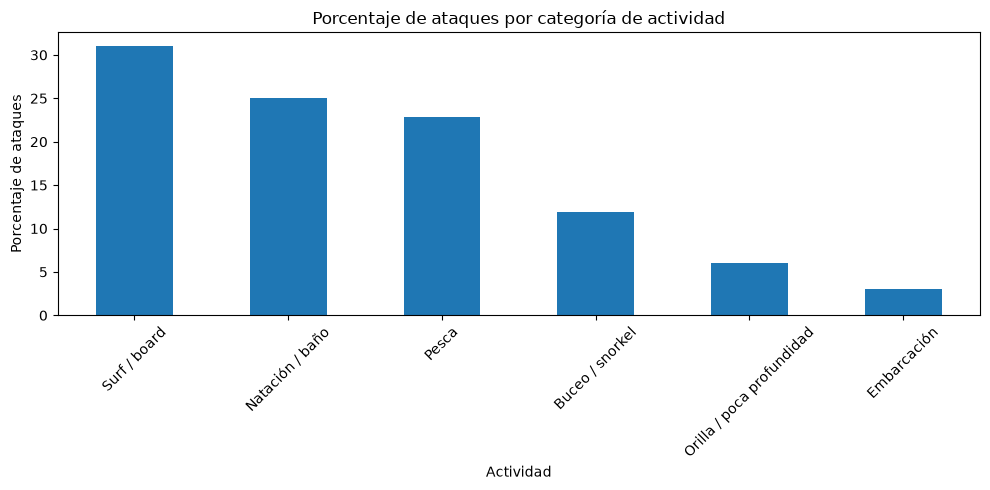

In [91]:
cuadro_actividades["Porcentaje"].plot(kind="bar", figsize=(10,5))

plt.title("Porcentaje de ataques por categoría de actividad")
plt.xlabel("Actividad")
plt.ylabel("Porcentaje de ataques")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Analisis complemtentario por edad con actividades
Para complementar los datos anteriores y corroborar si en todas las edades se mantiene una cantidad similar.

Como vimos antes age es texto tenemos que convertirlo a numerico

In [92]:
df_limpio["Age_num"] = pd.to_numeric(df_limpio["Age"], errors="coerce")

y creamos rangos etarios para poder analizar

In [93]:
bins = [0, 12, 18, 30, 45, 60, 100]
labels = ["0-12", "13-18", "19-30", "31-45", "46-60", "60+"]

df_limpio["Rango_Edad"] = pd.cut(
    df_limpio["Age_num"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [94]:
df_limpio["Rango_Edad"].value_counts().sort_index()

Rango_Edad
0-12      279
13-18     776
19-30    1211
31-45     693
46-60     322
60+        88
Name: count, dtype: int64

In [95]:
df_edad_actividad = df_limpio[
    df_limpio["Rango_Edad"].notna() &
    ~df_limpio["Actividad_categoria"].isin(["Otra", "Sin dato"])].copy()

In [96]:
tabla_edad_actividad = pd.crosstab(
    df_edad_actividad["Rango_Edad"],
    df_edad_actividad["Actividad_categoria"],
    normalize="index") * 100

tabla_edad_actividad = tabla_edad_actividad.round(2)

tabla_edad_actividad

Actividad_categoria,Buceo / snorkel,Embarcación,Natación / baño,Orilla / poca profundidad,Pesca,Surf / board
Rango_Edad,,,,,,
0-12,2.75,0.00,41.74,23.39,5.50,26.61
13-18,5.81,0.58,29.51,9.88,8.58,45.64
19-30,9.92,1.11,22.34,4.91,19.74,41.98
31-45,16.64,1.92,18.08,5.92,23.52,33.92
46-60,17.79,2.01,22.15,5.70,19.46,32.89
60+,15.79,1.32,32.89,13.16,18.42,18.42


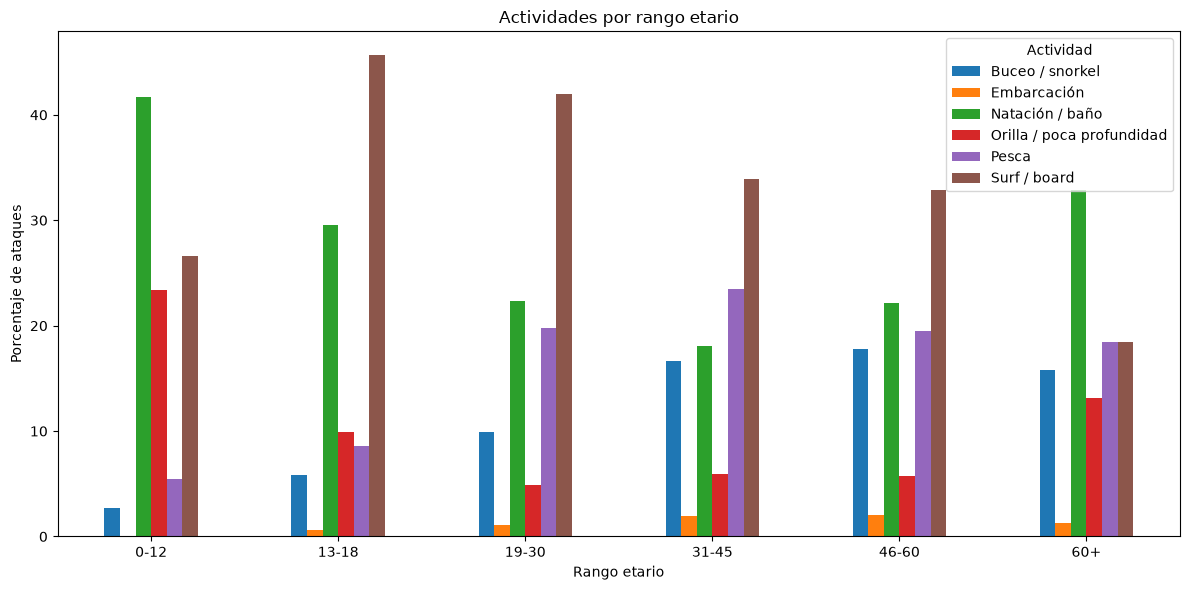

In [97]:
tabla_edad_actividad.plot(kind="bar", figsize=(12,6))

plt.title("Actividades por rango etario")
plt.xlabel("Rango etario")
plt.ylabel("Porcentaje de ataques")
plt.xticks(rotation=0)
plt.legend(title="Actividad")
plt.tight_layout()
plt.show()

##Pregunta 2: ¿Qué porcentaje de los ataques registrados fueron fatales?

In [98]:
df_limpio["Fatal (Y/N)"].value_counts(dropna=False)

Fatal (Y/N)
N          4293
Y          1388
NaN         548
UNKNOWN      71
 N            7
M             1
2017          1
N             1
y             1
Name: count, dtype: int64

###Limpiamos los valores de la columna
Eliminamos espacios, pasamos todo a mayusculas unificamos Y como fatal y N como no fatal y excluimos valores nulos o inconsistentes

In [99]:
df_limpio["Fatal_limpio"] = df_limpio["Fatal (Y/N)"].astype(str).str.strip().str.upper()

df_limpio["Fatal_limpio"] = df_limpio["Fatal_limpio"].replace({"Y": "Fatal","N": "No fatal"})

df_fatalidad = df_limpio[df_limpio["Fatal_limpio"].isin(["Fatal", "No fatal"])].copy()

df_fatalidad["Fatal_limpio"].value_counts()

Fatal_limpio
No fatal    4301
Fatal       1389
Name: count, dtype: int64

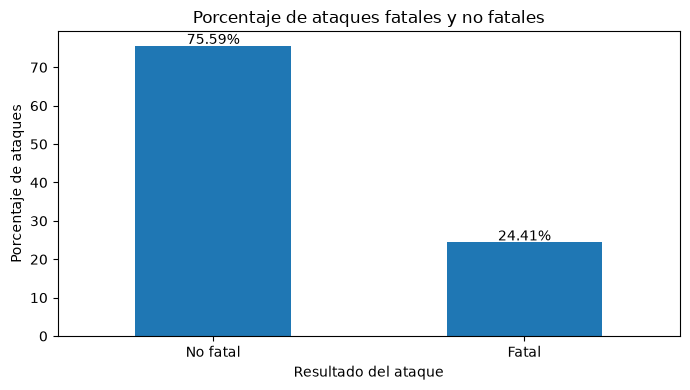

In [100]:
porcentaje_fatalidad = df_fatalidad["Fatal_limpio"].value_counts(normalize=True) * 100

ax = porcentaje_fatalidad.plot(kind="bar", figsize=(7,4))

plt.title("Porcentaje de ataques fatales y no fatales")
plt.xlabel("Resultado del ataque")
plt.ylabel("Porcentaje de ataques")
plt.xticks(rotation=0)

for i, valor in enumerate(porcentaje_fatalidad):
    ax.text(i, valor + 0.5, f"{valor:.2f}%", ha="center")

plt.tight_layout()
plt.show()

##Analisis complementario: fatalidad por actividad

In [101]:
df_fatal_actividad = df_limpio[
    df_limpio["Fatal_limpio"].isin(["Fatal", "No fatal"]) &
    ~df_limpio["Actividad_categoria"].isin(["Otra", "Sin dato"])].copy()

In [102]:
tabla_fatal_actividad = pd.crosstab(
    df_fatal_actividad["Actividad_categoria"],
    df_fatal_actividad["Fatal_limpio"],
    normalize="index"
) * 100

tabla_fatal_actividad = tabla_fatal_actividad.reindex(
    columns=["No fatal", "Fatal"],
    fill_value=0
).round(2)

tabla_fatal_actividad = tabla_fatal_actividad.sort_values(
    "Fatal",
    ascending=False
)

tabla_fatal_actividad

Fatal_limpio,No fatal,Fatal
Actividad_categoria,,
Natación / baño,57.09,42.91
Embarcación,63.91,36.09
Buceo / snorkel,75.55,24.45
Pesca,85.40,14.60
Orilla / poca profundidad,85.81,14.19
Surf / board,87.43,12.57


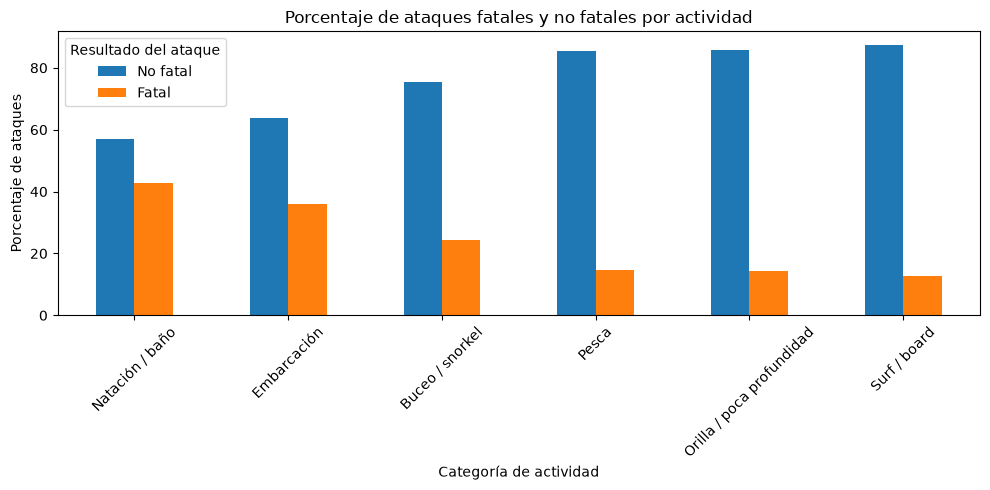

In [103]:
ax = tabla_fatal_actividad.plot(kind="bar", figsize=(10,5))

plt.title("Porcentaje de ataques fatales y no fatales por actividad")
plt.xlabel("Categoría de actividad")
plt.ylabel("Porcentaje de ataques")
plt.xticks(rotation=45)
plt.legend(title="Resultado del ataque")

plt.tight_layout()
plt.show()

In [104]:
resumen_comparativo = cuadro_actividades.copy()

resumen_comparativo = resumen_comparativo.join(
    tabla_fatal_actividad,
    how="left"
)

resumen_comparativo = resumen_comparativo.rename(columns={
    "Porcentaje": "Porcentaje_casos",
    "No fatal": "Porcentaje_no_fatal",
    "Fatal": "Porcentaje_fatal"
})

resumen_comparativo

,Cantidad,Porcentaje_casos,Porcentaje_no_fatal,Porcentaje_fatal
Actividad_categoria,,,,
Surf / board,1579,31.05,87.43,12.57
Natación / baño,1276,25.09,57.09,42.91
Pesca,1164,22.89,85.40,14.60
Buceo / snorkel,607,11.93,75.55,24.45
Orilla / poca profundidad,305,6.00,85.81,14.19
Embarcación,155,3.05,63.91,36.09


Se contruye un "indice de peligrosidad" relativa combinando el % de casos de cada actividad con el % de fatalidad, respecto al maximo de todas las actividades y promediandolos

In [105]:
resumen_comparativo["Puntaje_frecuencia"] = (
    resumen_comparativo["Porcentaje_casos"] /
    resumen_comparativo["Porcentaje_casos"].max() * 100)

resumen_comparativo["Puntaje_fatalidad"] = (
    resumen_comparativo["Porcentaje_fatal"] /
    resumen_comparativo["Porcentaje_fatal"].max() * 100)

resumen_comparativo["Indice_peligrosidad_relativa"] = (
    (resumen_comparativo["Puntaje_frecuencia"] +
     resumen_comparativo["Puntaje_fatalidad"]) / 2).round(2)

resumen_comparativo_final = resumen_comparativo[
    [
        "Porcentaje_casos",
        "Porcentaje_fatal",
        "Indice_peligrosidad_relativa"
    ]
].sort_values("Indice_peligrosidad_relativa", ascending=False)

resumen_comparativo_final

,Porcentaje_casos,Porcentaje_fatal,Indice_peligrosidad_relativa
Actividad_categoria,,,
Natación / baño,25.09,42.91,90.40
Surf / board,31.05,12.57,64.65
Pesca,22.89,14.60,53.87
Buceo / snorkel,11.93,24.45,47.70
Embarcación,3.05,36.09,46.96
Orilla / poca profundidad,6.00,14.19,26.20


##Limitaciones
El analisis se basa unicamente en los registros disponibles en este dateset por lo tanto no es posible calcular el riesgo real de ataques por actividad ya que no tenemos la cantidad total de personas que plactican cada actividad. Ademas, la columna "Age" presenta gran cantidad de valores faltantes, por lo cual se tomo solo como variable complementaria.

##Conclusiones

Se observo que la categoria Surf/Board concentra la mayor cantidad de ataques registrados y al cruzarlo con la columna edad se refuerza su presencia dentro del dataset, pero no pudiendo afirmar que sea asi fuera del mismo.

En relacion con la fatalidad, si bien la mayoria de los ataques resulta no fatales, dentro de las categorias varia bastante pero manteniendose siempre por encima la cantidad de casos no fatales.

Finalmente, el indice de peligrosidad relativa muestra una
comparacion interna del dataset combinando frecuencia de casos y porcentaje de fatalidad, pero no debe interpretarse como una medida real de riesgo.

